In [130]:
import logging
import os
import sys


from dotenv import load_dotenv
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path

import polars as pl
import numpy as np

# Env
load_dotenv("../.env", override=True)
INSTALL_PATH = os.environ["INSTALL_PATH"]
URL_AF = os.environ["API_URL_ALPHAFOLD_STRUCTPRED"]
sys.path.append(str(Path(INSTALL_PATH).resolve()))

# Modules
from modules.pymol_align import get_alphafold_structures, pymol_align_pairs

# Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s:%(name)s:%(message)s"
)
logger = logging.getLogger(__name__)

In [78]:
# ────────────────────────────────────────────────────────────
#      Args
# ────────────────────────────────────────────────────────────

DATA_FILE = f"{INSTALL_PATH}/results/explore_zorya/zorya_pymol_ann_n=300.tsv"
DATA_FILE_GOLDSTANDARD = f"{INSTALL_PATH}/lit_review_manual/___bacterial_immuneSystem_goldStandard_manual.tsv"
OUT_DIR = Path(f"{INSTALL_PATH}/results/update_report_2_pairwise_aln")
OUT_DIR_AF = Path(f"{INSTALL_PATH}/data_local/alphafold_structures")
OUT_DIR_PM = Path(f"{INSTALL_PATH}/data_local/pymol_alignments/super")
OUT_DIR_PDB = Path(f"{INSTALL_PATH}/data_local/pdb_structures")

API_URL_PDB_QUERY = os.environ["API_URL_PDB_QUERY"]
API_URL_PDB_DOWNLOAD = os.environ["API_URL_PDB_DOWNLOAD"]

NEGLOG_EVALUE_COL = "neg_log(evalue_foldseek)"
PM_RMSD_COL = "PyMOL_RMSD"

COL_GS_BACT_PROT_ID = "Bacterial_UniProt_accession"
COL_GS_HS_PROT_ID = "Human_UniProt_accession"

In [57]:
# ────────────────────────────────────────────────────────────
#      In
# ────────────────────────────────────────────────────────────

df = pl.read_csv(
    DATA_FILE,
    separator="\t",
    has_header=True
)

df_gs = pl.read_csv(
    DATA_FILE_GOLDSTANDARD,
    separator="\t",
    encoding="latin1",
    null_values=["Not assessed", "Not assesed", "NA"],
    has_header=True
)

df

accession_in_sys,type,subtype,species,sys_id,sys_beg,sys_end,duplicate_count,rank,defense_system_protein_id,defense_system_cluster_id,cluster_id,protein_id,evalue,cluFlag,fident,alnlen,mismatch,gapopen,qstart,qend,tstart,tend,evalue_foldseek,bits,Reviewed,Entry Name,Protein names,Gene Names,Organism,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),…,CDD,FunFam,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,Query_range,Query_length,Human_prot_total_length,Human_prot_domain_match,Human_domain_percentage,Query_percentage,Query_overlap_w_Human_protein,Human_domain_note,Human_domain_evidence,Target_range,Target_length,Bacterial_prot_total_length,Bacterial_prot_domain_match,Bacterial_domain_percentage,Target_percentage,Target_overlap_w_Bacterial_protein,Bacterial_domain_note,Bacterial_domain_evidence,Bacterial_Human_Len_Ratio,Query_Target_Overlap_Length,Overlap_ratio,Protein_length_difference,neg_log(evalue_foldseek),defense_system_protein_AF_file,protein_AF_file,PyMOL_aligned_filePath,PyMOL_RMSD,PyMOL_aligned_atoms
str,str,str,str,str,str,str,i64,i64,str,str,str,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,f64,i64,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,i64,i64,str,f64,f64,f64,str,str,str,i64,i64,str,f64,f64,f64,str,str,f64,f64,f64,f64,f64,str,str,str,f64,i64
"""WP_088134450.1""","""Zorya""","""Zorya_TypeI""","""Vibrio gazogenes""","""GCF_002196515_NZ_CP018835_Zory…","""GCF_002196515.1_NZ_CP018835_03…","""GCF_002196515.1_NZ_CP018835_03…",1,202,"""A0A1Z2SID7""","""A0A1W9LKN2""","""A0A3Q0EX91""","""F5GZT0""",0.066,1,0.11,298,249,0.0,96,376,35,332,0.03259,29,"""unreviewed""","""F5GZT0_HUMAN""","""Meiotic double-stranded break …","""MEI1""","""Homo sapiens (Human)""",null,null,"""MEI1""",null,"""UP000005640: Chromosome 22""",null,null,…,null,null,"""1.25.10.10; Leucine-rich Repea…","""IPR011989; ARM-like.;""IPR01602…","""PTHR12044; BCL2 INTERACTING ME…",null,null,null,null,"""96.0..376.0""",281,506,null,null,null,null,null,null,"""35.0..332.0""",298,487,"""27..453""",69.79,100.0,61.19,"""['Zorya protein ZorC EH']""","""['ECO:0000259|Pfam:PF15611']""",0.962451,281.0,0.577002,0.037549,1.486916,"""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…",18.0215,1734
"""WP_048884341.1""","""Zorya""","""Zorya_TypeI""","""Aurantiacibacter atlanticus""","""GCF_001077815_NZ_CP011310_Zory…","""GCF_001077815.2_NZ_CP011310_00…","""GCF_001077815.2_NZ_CP011310_00…",1,202,"""A0A0H4VDC2""","""A0A101WRB2""","""L8LWH0""","""B3KPF2""",0.8219,2,0.17,86,56,0.0,155,240,1116,1184,2.627,5,"""unreviewed""","""B3KPF2_HUMAN""","""dynamin GTPase (EC 3.6.5.5)""",null,"""Homo sapiens (Human)""",null,null,null,null,null,"""endocytosis [GO:0006897]""","""microtubule [GO:0005874]""",…,"""cd08771; DLP_1; 1.;""","""1.20.120.1240:FF:000014; Dynam…","""1.20.120.1240; Dynamin, middle…","""IPR022812; Dynamin.;""IPR001401…","""PTHR11566; DYNAMIN; 1.;""PTHR11…","""PF01031; Dynamin_M; 1.;""PF0035…","""PS00410; G_DYNAMIN_1; 1.;""PS51…","""SM00053; DYNc; 1.;""",null,"""155.0..240.0""",86,555,"""28..294""",32.21,100.0,15.5,"""['Dynamin-type G']""","""['ECO:0000259|PROSITE:PS51718'…","""1116.0..1184.0""",69,1243,null,null,null,null,null,null,2.23964,69.0,0.124324,1.23964,-0.41946,"""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…",24.708685,567
"""WP_013220829.1""","""Zorya""","""Zorya_TypeI""","""Nitrosococcus watsonii""","""GCF_000143085_NC_014315_Zorya_…","""GCF_000143085.1_NC_014315_0187…","""GCF_000143085.1_NC_014315_0187…",1,202,"""D8K760""","""A0A2D9ZZN8""","""B3RZ88""","""Q99705""",0.03944,1,0.083,363,301,0.0,88,416,1,363,0.5326,11,"""reviewed""","""MCHR1_HUMAN""","""Melanin-concentrating hormone …","""MCHR1 GPR24 SLC1""","""Homo sapiens (Human)""",null,null,"""MCHR1""","""GPR24 SLC1""","""UP000005640: C

In [58]:
df_gs

PMID,Paper_title,Bacterial_gene_name,Bacterial_species,Bacterial_UniProt_accession,Bacterial_AA_sequence,Human_gene_name,Human_UniProt_accession,Human_AA_sequence,Similiarity_to_hs_note,Include,Inclusion_reason,Bacterial_system,Function_in_bacteria,Functional_assay,Cloned_into_organism,Did_structural_validation,Screening_source,Note
i64,str,str,str,str,str,str,str,str,str,bool,str,str,str,str,str,bool,str,str
12110595,"""tadA, an essential tRNA-specif…","""tadA""","""Escherichia coli""","""P68398""",null,null,null,null,null,false,"""No obvious immune function""",null,"""tRNA binding; tRNA deamination""",null,null,null,"""C Trost""","""34% sequence-similar to yeast …"
30787435,"""Bacterial cGAS-like enzymes sy…","""dncV""","""Vibrio cholerae""","""Q9KVG7""",null,"""CGAS""","""Q8N884""","""MQPWHGKAMQRASEAGATAPKASARNARGA…","""Unquantified loose sequence si…",false,"""Functional assay, homology to …","""CBASS""","""abortive infection; intracellu…","""product radiolabelling""","""HEK293T""",true,"""C Trost""","""protein full name: Cyclic GMP-…"
30787435,"""Bacterial cGAS-like enzymes sy…","""cdnE""","""Escherichia coli""","""Q6XGD5""","""MGIPESQLDTWSHQGSIAQSASTYSIIKNA…","""CGAS""","""Q8N884""","""MQPWHGKAMQRASEAGATAPKASARNARGA…","""Unquantified loose sequence si…",true,"""Functional assay, homology to …","""CBASS""","""abortive infection; intracellu…","""biochemical deconvolution; act…",null,true,"""C Trost""","""protein full name: Cyclic UMP-…"
30787435,"""Bacterial cGAS-like enzymes sy…","""cdnE""","""Rhodothermus marinus""","""G2SLH8""","""MPVPESQLERWSHQGATTTAKKTHESIRAA…","""CGAS""","""Q8N884""","""MQPWHGKAMQRASEAGATAPKASARNARGA…","""Unquantified loose sequence si…",true,"""Functional assay, homology to …","""CBASS""","""abortive infection; intracellu…","""product radiolabelling""",null,true,"""C Trost""",null
31695182,"""The pan-immune system of bacte…","""Cas1""","""Escherichia coli""","""A0A1Q4PK74""",null,null,null,null,null,false,"""Review""","""CRISPR Cas""",null,null,null,null,"""C Trost""",null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
32937646,"""Prokaryotic viperins produce d…","""vip47""","""Flammeovirga pacifica""","""A0A1S1YUU1""","""MNKLVSGNNIIPSVNFHLWEPCNMRCKFCF…","""RSAD2""","""Q8WXG1""","""MWVLTPAAFAGKLLSVFRQPLSSLWRSLVP…","""Authors claim human homology b…",true,null,"""Vipirin""","""antiphage; RNA polymerase inih…","""T7 plaque assay; mutation assa…","""Escherichia coli""",null,"""M Umanowicz""","""From fig 1 description: ""Homol…"
32937646,"""Prokaryotic viperins produce d…","""vip50""","""Thermoplasmatales archaeon""","""A0A110A2W7""","""MNTETTSVRKFRSANIHIYGKCNYRCEHCF…","""RSAD2""","""Q8WXG1""","""MWVLTPAAFAGKLLSVFRQPLSSLWRSLVP…","""Authors claim human homology b…",true,null,"""Vipirin""","""antiphage; RNA polymerase inih…","""T7 plaque assay; mutation assa…","""Escherichia coli""",null,"""M Umanowicz""","""From fig 1 description: ""Homol…"
32937646,"""Prokaryotic viperins produce d…","""vip56""","""Fibrobacter sp.""","""A0A1M7D0R2""","""MNIKTIVINWHITESCNYKCKYCFAKWNRV…","""RSAD2""","""Q8WXG1""","""MWVLTPAAFAGKLLSVFRQPLSSLWRSLVP…","""Authors claim human homology b…",true,null,"""Vipirin""","""antiphage; RNA polymerase inih…","""T7 plaque assay; mutation assa…","""Escherichia coli""",null,"""M Umanowicz""","""From fig 1 description: ""Homol…"


In [9]:
# ────────────────────────────────────────────────────────────
#      Isolate point of interest (-30, 3.4)
# ────────────────────────────────────────────────────────────

poi_1 = df.filter(
    (pl.col(PM_RMSD_COL) <= 1.5) &
    (pl.col(NEGLOG_EVALUE_COL) >= 30)
)

poi_1_val = poi_1["PyMOL_aligned_filePath"].item()
print(str(poi_1_val))

/home/juliandeanmoran/___git_repos/BISSH/data_local/pymol_alignments/super/A0A0H4VDC2_X5D2E5_aligned.pse


In [16]:
# ────────────────────────────────────────────────────────────
#      Isolate point of interest (-26, 1.7)
# ────────────────────────────────────────────────────────────

poi_2 = df.filter(
    (pl.col(PM_RMSD_COL) <= 1.6) &
    (pl.col(PM_RMSD_COL) >= 1.5) &
    (pl.col(NEGLOG_EVALUE_COL) >= 26) &
    (pl.col(NEGLOG_EVALUE_COL) <= 28)
)

poi_2_val = poi_2["PyMOL_aligned_filePath"].item()
print(str(poi_2_val))

/home/juliandeanmoran/___git_repos/BISSH/data_local/pymol_alignments/super/A0A5B8XTL3_A0A0A0MSH9_aligned.pse


In [21]:
# ────────────────────────────────────────────────────────────
#      Isolate point of interest (-26, 1.7)
# ────────────────────────────────────────────────────────────

poi_3 = df.filter(
    (pl.col(PM_RMSD_COL) <= 1.4) &
    (pl.col(NEGLOG_EVALUE_COL) >= 12.2) &
    (pl.col(NEGLOG_EVALUE_COL) <= 13)
)

poi_3

poi_3_val = poi_3["PyMOL_aligned_filePath"].item()
print(str(poi_3_val))

/home/juliandeanmoran/___git_repos/BISSH/data_local/pymol_alignments/super/A0A4Y6RC84_B4DLS6_aligned.pse


In [26]:
# ────────────────────────────────────────────────────────────
#      Isolate point of interest (-30, 3.4)
# ────────────────────────────────────────────────────────────

poi_4 = df.filter(
    (pl.col(PM_RMSD_COL) >= 3.0) &
    (pl.col(NEGLOG_EVALUE_COL) >= 30)
)

poi_4

poi_4_val = poi_4["PyMOL_aligned_filePath"].item()
print(str(poi_4_val))

/home/juliandeanmoran/___git_repos/BISSH/data_local/pymol_alignments/super/A0A6L8M512_Q8N6J1_aligned.pse


In [92]:
# ────────────────────────────────────────────────────────────
#      Gold standard: get PyMol alignments
# ────────────────────────────────────────────────────────────

df_gs_fl = df_gs.filter(
    (~pl.col(COL_GS_BACT_PROT_ID).is_null()) &
    (~pl.col(COL_GS_HS_PROT_ID).is_null()) &
    (pl.col("Include") == True)
).unique([COL_GS_BACT_PROT_ID, COL_GS_HS_PROT_ID])

df_af, col_bact_struct, col_hs_struct = get_alphafold_structures(
    df_uniprot_ids=df_gs_fl,
    col_query_uniprot_id=COL_GS_BACT_PROT_ID,
    col_target_uniprot_id=COL_GS_HS_PROT_ID,
    out_dir=OUT_DIR_AF,
    api_endpoint=URL_AF
)

df_pm = pymol_align_pairs(
    df_structure_files=df_af,
    col_query_id=COL_GS_BACT_PROT_ID,
    col_query_struct=col_bact_struct,
    col_target_id=COL_GS_HS_PROT_ID,
    col_target_struct=col_hs_struct,
    out_dir=OUT_DIR_PM,
    pymol_align_method="super"
)

INFO:modules.pymol_align:============================================================
INFO:modules.pymol_align:Query protein:
INFO:modules.pymol_align:
INFO:modules.pymol_align:Target protein:
INFO:modules.pymol_align:============================================================
INFO:modules.pymol_align:Query protein:
INFO:modules.pymol_align:
INFO:modules.pymol_align:Target protein:
INFO:modules.pymol_align:============================================================
INFO:modules.pymol_align:Query protein:
INFO:modules.pymol_align:
INFO:modules.pymol_align:Target protein:
INFO:modules.pymol_align:============================================================
INFO:modules.pymol_align:Query protein:


INFO:modules.pymol_align:
INFO:modules.pymol_align:Target protein:
INFO:modules.pymol_align:============================================================
INFO:modules.pymol_align:Query protein:
INFO:modules.pymol_align:
INFO:modules.pymol_align:Target protein:
INFO:modules.pymol_align:============================================================
INFO:modules.pymol_align:Query protein:
INFO:modules.pymol_align:
INFO:modules.pymol_align:Target protein:
INFO:modules.pymol_align:============================================================
INFO:modules.pymol_align:Query protein:
INFO:modules.pymol_align:
INFO:modules.pymol_align:Target protein:
INFO:modules.pymol_align:============================================================
INFO:modules.pymol_align:Query protein:
INFO:modules.pymol_align:
INFO:modules.pymol_align:Target protein:
INFO:modules.pymol_align:============================================================
INFO:modules.pymol_align:Query protein:
INFO:modules.pymol_align:
INFO:modu

In [98]:
# ────────────────────────────────────────────────────────────
#      Out
# ────────────────────────────────────────────────────────────

df_pm.write_csv(
    OUT_DIR / f"gold_standard_list_pymol_aln_n={len(df_pm)}.tsv",
    separator="\t",
    include_header=True
)

df_pm

PMID,Paper_title,Bacterial_gene_name,Bacterial_species,Bacterial_UniProt_accession,Bacterial_AA_sequence,Human_gene_name,Human_UniProt_accession,Human_AA_sequence,Similiarity_to_hs_note,Include,Inclusion_reason,Bacterial_system,Function_in_bacteria,Functional_assay,Cloned_into_organism,Did_structural_validation,Screening_source,Note,Bacterial_protein_AF_file,Human_protein_AF_file,PyMOL_aligned_filePath,PyMOL_RMSD,PyMOL_aligned_atoms
i64,str,str,str,str,str,str,str,str,str,bool,str,str,str,str,str,bool,str,str,str,str,str,f64,i64
32937646,"""Prokaryotic viperins produce d…","""vip56""","""Fibrobacter sp.""","""A0A1M7D0R2""","""MNIKTIVINWHITESCNYKCKYCFAKWNRV…","""RSAD2""","""Q8WXG1""","""MWVLTPAAFAGKLLSVFRQPLSSLWRSLVP…","""Authors claim human homology b…",true,null,"""Vipirin""","""antiphage; RNA polymerase inih…","""T7 plaque assay; mutation assa…","""Escherichia coli""",null,"""M Umanowicz""","""From fig 1 description: ""Homol…","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…",1.344198,1224
40705877,"""A human homolog of SIR2 antiph…","""ThsA""","""Bacillus cereus""","""J8G6Z1""","""MKMNPIVELFIKDFTKEVMEENAAIFAGAG…","""SIRT7""","""Q9NRC8""","""MAAGGLSRSERKAAERVRRLREEQQRERLR…",null,true,"""Human homology""","""SIR2 antiphage; Thoeris""","""antiphage; NAD+ hydrolysis; NA…",null,null,null,"""ChatGPT""","""AKA ""Thoeris A"" by authors; an…","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…",10.16119,412
30787435,"""Bacterial cGAS-like enzymes sy…","""cdnE""","""Rhodothermus marinus""","""G2SLH8""","""MPVPESQLERWSHQGATTTAKKTHESIRAA…","""CGAS""","""Q8N884""","""MQPWHGKAMQRASEAGATAPKASARNARGA…","""Unquantified loose sequence si…",true,"""Functional assay, homology to …","""CBASS""","""abortive infection; intracellu…","""product radiolabelling""",null,true,"""C Trost""",null,"""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…",5.593334,1285
32937646,"""Prokaryotic viperins produce d…","""vip8""","""Psychrobacter lutiphocae""","""P0DW49""","""MHNHNKIANKELVVNWHITEACNYRCGYCF…","""RSAD2""","""Q8WXG1""","""MWVLTPAAFAGKLLSVFRQPLSSLWRSLVP…","""Authors claim human homology b…",true,null,"""Vipirin""","""antiphage; RNA polymerase inih…","""T7 plaque assay; mutation assa…","""Escherichia coli""",null,"""M Umanowicz""","""From fig 1 description: ""Homol…","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…",1.244299,1288
32937646,"""Prokaryotic viperins produce d…","""vip60""","""Lacinutrix mariniflava""","""P0DW53""","""MKTKITLSGFAGTGKSTVGKRIQEQLNFEF…","""RSAD2""","""Q8WXG1""","""MWVLTPAAFAGKLLSVFRQPLSSLWRSLVP…","""Authors claim human homology b…",true,null,"""Vipirin""","""antiphage; RNA polymerase inih…","""T7 plaque assay; mutation assa…","""Escherichia coli""",null,"""M Umanowicz""","""From fig 1 description: ""Homol…","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…",0.873875,1470
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
32937646,"""Prokaryotic viperins produce d…","""vip58""","""Pseudoalteromonas ulvae""","""A0A244CMP0""","""MEIHMTSIQELVINFHMTEACNYRCGYCYA…","""RSAD2""","""Q8WXG1""","""MWVLTPAAFAGKLLSVFRQPLSSLWRSLVP…","""Authors claim human homology b…",true,null,"""Vipirin""","""antiphage; RNA polymerase inih…","""T7 plaque assay; mutation assa…","""Escherichia coli""",null,"""M Umanowicz""","""From fig 1 description: ""Homol…","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…","""/home/juliandeanmoran/___git_r…",1.049916,1303
32937646,"""Prokaryotic viperins produce d…","""vip50""","""Thermoplasmatales archaeon""","""A0A110A2W7""","""MNTETTSVRKFRSANIHIYGKCNYRCEHCF…","""RSAD2""","""Q8WXG1""","""MWVLTPAAFAGKLLSVFRQPLSSLWRSLVP…","""Authors claim human homology b…",true,null,"""Vipirin""","""antiphage; RNA polymerase inih…","""T7 plaque

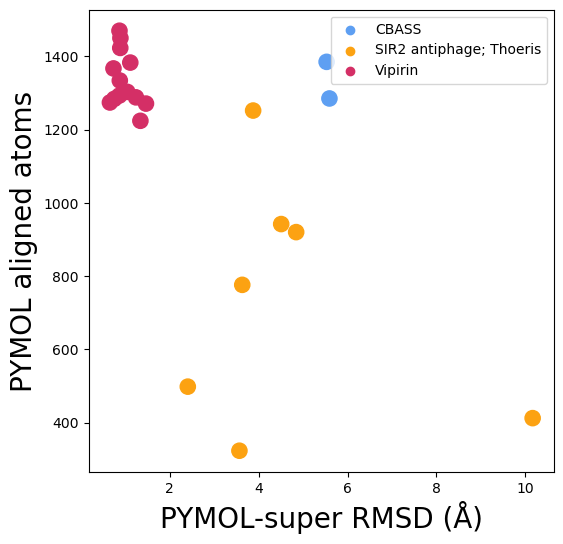

In [144]:
# ────────────────────────────────────────────────────────────
#      Scatter plot for gold standard
# ────────────────────────────────────────────────────────────

def out_plot(
        figure: plt.Figure,
        out_path: str,
        svg: bool = True,
        png_dpi: int = 1080
) -> None:
    out_path = Path(out_path)
    if svg:
        figure.savefig(out_path.with_suffix(".svg"))
    if png_dpi:
        figure.savefig(out_path.with_suffix(".png"), dpi=png_dpi)
    return None

def plot_scatter(
    df: pl.DataFrame,
    col_x: str,
    col_y: str,
    colour_col: str = None,
    plot_title: str = "",
    title_font_size: int = 14,
    y_axis_label: str = "Y",
    x_axis_label: str = "X",
    axis_equal_aspect_ratio = False,
    dot_size: float = 40,
    dot_colour: str = "blue",
    cmap: str = "viridis",
    dot_alpha: float = 1.0,
    threshold: float = None,
    axis_label_font_size: int = 20,
    dims: tuple[int, int] = (6, 6),
    out_path = None,
) -> None:

    x = df[col_x].to_numpy()
    y = df[col_y].to_numpy()

    fig, ax = plt.subplots(figsize=dims)

    if colour_col is not None:
        c = df[colour_col].to_numpy()

        # detect if categorical
        if c.dtype.kind in {"U", "O"}: # string/object dtype
            categories = np.unique(c)
            color_map = plt.get_cmap(cmap, len(categories))

            for i, cat in enumerate(categories):
                ax.scatter([], [], color=color_map(i), label=cat)

            cat_to_num = {cat: i for i, cat in enumerate(categories)}
            c_mapped = np.array([cat_to_num[val] for val in c])
            sc = ax.scatter(
                x,
                y,
                c=c_mapped,
                cmap=color_map,
                s=dot_size,
                alpha=dot_alpha,
                label=None
            )

        else:
            c = df[colour_col].to_numpy()
            sc = ax.scatter(
                x,
                y,
                c=c,
                cmap=cmap,
                s=dot_size,
                alpha=dot_alpha,
                label=f"n = {len(df)}"
            )

            cbar = plt.colorbar(sc, ax=ax)
            cbar.set_label(colour_col)

            # ensure full range is shown
            sc.set_clim(c.min(), c.max())

    else:
        ax.scatter(x, y, s=dot_size, c=dot_colour, alpha=dot_alpha, label=f"n = {len(df)}")
    
    ax.legend()

    if axis_equal_aspect_ratio:
        xmin, xmax = x.min(), x.max()
        ymin, ymax = y.min(), y.max()
        low = min(xmin, ymin)
        high = max(xmax, ymax)
        ax.set_xlim(low, high)
        ax.set_ylim(low, high)

    if threshold is not None:
        ax.axvline(threshold, linestyle="--", color="red")
        ax.axhline(threshold, linestyle="--", color="red")

    ax.set_title(plot_title, fontsize=title_font_size)
    ax.set_xlabel(x_axis_label, fontsize=axis_label_font_size)
    ax.set_ylabel(y_axis_label, fontsize=axis_label_font_size)

    if out_path is not None:
        out_plot(figure=fig, out_path=out_path, svg=True, png_dpi=1080)

    plt.show()


cmap_pymol_scatter = ListedColormap(["#5E9FF2", "#FCA212", "#D42F66"])

plot_scatter(
    df=df_pm,
    col_x="PyMOL_RMSD",
    col_y="PyMOL_aligned_atoms",
    colour_col="Bacterial_system",
    cmap=cmap_pymol_scatter,
    dot_alpha=1.0,
    dot_size=120,
    x_axis_label='PYMOL-super RMSD (Å)',
    y_axis_label='PYMOL aligned atoms',
    out_path=f"{OUT_DIR}/scatter_pymolRMSD_pymolAln_n={len(df_pm)}",
)

In [73]:
import requests

def get_pdb_ids_from_uniprot(
        uniprot_id: str,
        out_dir: Path,
        pdb_query_url: str,
        pdb_download_url: str
    ):
    url = pdb_query_url
    query = {
        "query": {
            "type": "terminal",
            "service": "text",
            "parameters": {
                "attribute": "rcsb_polymer_entity_container_identifiers.reference_sequence_identifiers.database_accession",
                "operator": "exact_match",
                "value": uniprot_id
            }
        },
        "return_type": "entry"
    }
    r = requests.post(url, json=query)
    r.raise_for_status()
    data = r.json()
    pdb_ids = [res["identifier"] for res in data.get("result_set", [])]

    downloaded = []
    for pdb_id in pdb_ids:
        pdb_url = f"{pdb_download_url}/{pdb_id}.pdb"
        out_path = out_dir / f"{uniprot_id}_{pdb_id}.pdb"

        resp = requests.get(pdb_url)
        if resp.status_code == 200:
            out_path.write_bytes(resp.content)
            downloaded.append(out_path)

    return downloaded

In [74]:
df__ = df_gs_fl.filter(
    pl.col("Did_structural_validation") == True
)

_ = df__["Bacterial_UniProt_accession"][0]

file = get_pdb_ids_from_uniprot(
    _,
    out_dir=OUT_DIR_PDB,
    pdb_query_url=API_URL_PDB_QUERY,
    pdb_download_url=API_URL_PDB_DOWNLOAD
)
file

[PosixPath('/home/juliandeanmoran/___git_repos/BISSH/data_local/pdb_structures/G2SLH8_6E0K.pdb'),
 PosixPath('/home/juliandeanmoran/___git_repos/BISSH/data_local/pdb_structures/G2SLH8_6E0L.pdb')]